# Exercise 16: Model selection

This homework is designed to give you practice implementing model selection techniques, including best subset selection and forward/backward stepwise selection.

You won't need to load in any data for this homework, we will be simulating our own.

1. Best subset selection 1/4

 * Not all polynomial terms are included in the data

2. Forward and backwards stepwise selection 3/3
3. Training and test error 1/3

 * Incomplete


---
## 1. Best subset selection (4 points)

In this question, we will first generate simulated data, and then use it to perform best subset selection.

a) Use `rnorm()` to generate a dataset including a predictor $X$ of length $n = 100$ and a noise vector $\epsilon$ of length $n = 100$. Generate data for a response variable $Y$ of length $n = 100$ according to the model

$Y = \beta_0 + \beta_1X + \beta_2X^2 + \beta_3X^3 + \epsilon$

where $\beta_0$, $\beta_1$, $\beta_2$, and $\beta_3$ are constants of your choice.


In [ ]:
# WRITE YOUR CODE HERE
# a function for simulating data for two groups. Sample size is the number of people in each group
set.seed(123)
simulate_data <- function(sample_size) {
    # draw observation from a normal distribution
    x <- rnorm(sample_size, 0, 1)
    y <- 1 + 2*x + 3*(x^2) + 4*(x^3)+ rnorm(sample_size, 0, 1)
    return(data.frame(x = x, y = y))
}

df <- simulate_data(100)

str(df)

'data.frame':	100 obs. of  2 variables:
 $ x: num  -0.5605 -0.2302 1.5587 0.0705 0.1293 ...
 $ y: num  -0.593 0.907 26.307 0.81 0.366 ...


b) Use `regsubsets()` to perform best subset selection to determine the best model that contains the predictor variables $X$, $X^2$, . . . , $X^{10}$. Print the model summary.

In [ ]:
# WRITE YOUR CODE HERE
#install.packages("leaps")
library(leaps)
#?regsubsets
reg <- regsubsets(y ~ poly(x, 3), data = df)
reg.summary <- summary(reg)
reg.summary

Subset selection object
Call: regsubsets.formula(y ~ poly(x, 3), data = df)
3 Variables  (and intercept)
            Forced in Forced out
poly(x, 3)1     FALSE      FALSE
poly(x, 3)2     FALSE      FALSE
poly(x, 3)3     FALSE      FALSE
1 subsets of each size up to 3
Selection Algorithm: exhaustive
         poly(x, 3)1 poly(x, 3)2 poly(x, 3)3
1  ( 1 ) "*"         " "         " "        
2  ( 1 ) "*"         " "         "*"        
3  ( 1 ) "*"         "*"         "*"        

c) Plot the Mallows' Cp, Bayesian Information Criteria (BIC) and the adjusted coefficient of determination, $R^2$, for each model tested. Which is the best model? Report the coefficients of the best model.

In [ ]:
# WRITE YOUR CODE HERE

# Uncomment the model fit measures you want to look at.
library(ggplot2)

numvar = 1:length(reg.summary$rss)# Make a vector that lists the number of variables in sequence, from 1 to 19.
allfalse = rep(FALSE,length(reg.summary$rss))# Starting point for an indicator that marks the best model choice for each metric.

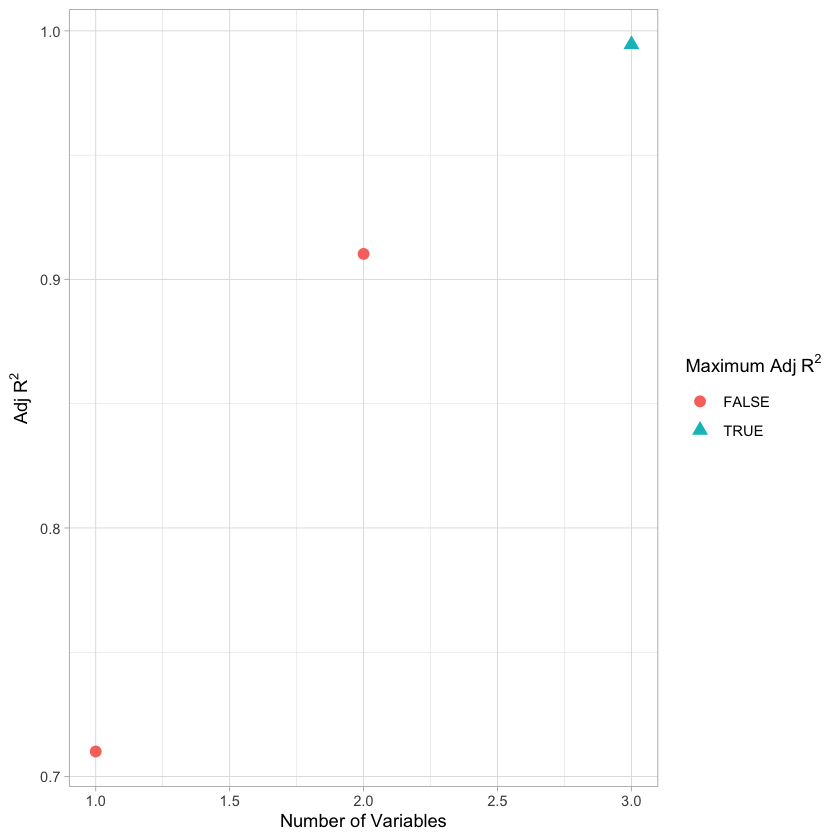

In [ ]:

#adjr2
adjr2_func <- function(numvar, adjr2){
    adjr2.df <- data.frame(numvar = numvar, adjr2 <- adjr2, maxadjr2 <- allfalse)
    adjr2.df$maxadjr2[which.max(adjr2)] <- TRUE
    x <- ggplot(adjr2.df,aes(x=numvar,y=adjr2,shape=maxadjr2,col=maxadjr2)) +
    geom_point(size=3) + theme_light() +
    labs(x = "Number of Variables", y = 'Adj'~R^2, color='Maximum Adj'~R^2, shape='Maximum Adj'~R^2)
    return(x)
    }

adjr2_func(numvar, reg.summary$adjr2)

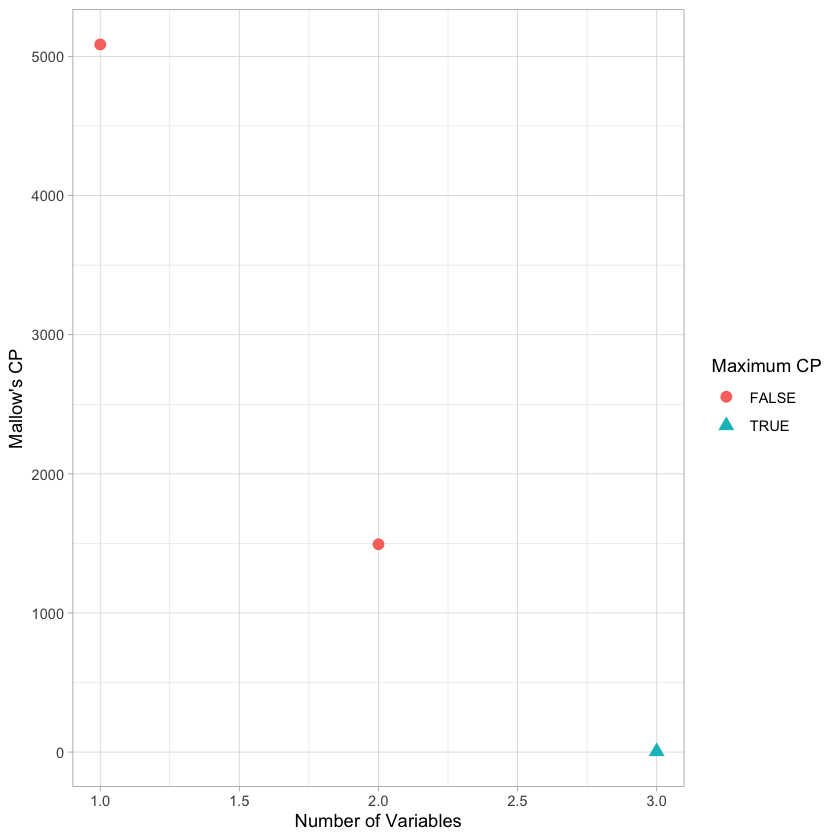

In [ ]:

#mallow's cp
cp_func <- function(numvar, cp){
    cp.df <- data.frame(numvar = numvar, cp <- cp, mincp <- allfalse)
    cp.df$mincp[which.min(cp)] <- TRUE
    x <- ggplot(cp.df,aes(x=numvar,y=cp,shape=mincp,col=mincp)) +
    geom_point(size=3) + theme_light() +
    labs(x = "Number of Variables", y = "Mallow's CP", color="Maximum CP", shape="Maximum CP")
    return(x)
}

cp_func(numvar, reg.summary$cp)

In [ ]:

#bic
bic_func <- function(numvar, bic_val){
 bic.df <- data.frame(numvar = numvar, bic <- bic_val, minbic <- allfalse)
 bic.df$minbic[which.min(bic)] <- TRUE
 x <- ggplot(bic.df,aes(x=numvar,y=bic,shape=minbic,col=minbic)) +
     geom_point(size=3) + theme_light() +
     labs(x = "Number of Variables", y = "BIC", color="Minimum BIC", shape="Minimum BIC")
     #which.min(reg.summary$bic)
     return(x)
}


[1] -115.6141 -229.3133 -505.2593

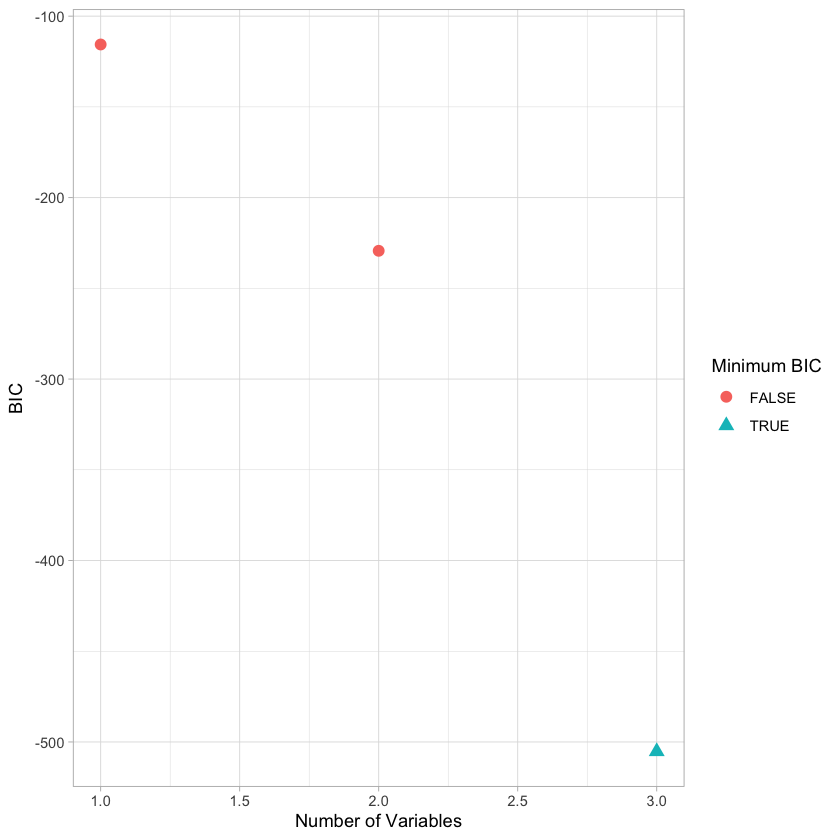

In [ ]:

bic_func(numvar, reg.summary$bic)

> The model with all three variables. Consistently has the lowest BIC, Mallow's CP, and highest R^2.

---
## 2. Forward and backwards stepwise selection (3 points)

Using the same simulated data from question 1, use forward stepwise selection, and backwards stepwise selections to determine the best model. Again, for both model selection methods, plot the Mallows' Cp, Bayesian Information Criteria (BIC) and the adjusted coefficient of determination, $R^2$, for each model tested. Report the coefficients of the best model.

a) Forward stepwise selection:

In [ ]:
reg <- regsubsets(y ~ poly(x, 3), data = df, method = 'forward')
step_model <- summary(reg)
numvar = 1:length(step_model$rss)# Make a vector that lists the number of variables in sequence, from 1 to 19.
allfalse = rep(FALSE,length(reg.summary$rss))
summary(reg)

Subset selection object
Call: regsubsets.formula(y ~ poly(x, 3), data = df, method = "forward")
3 Variables  (and intercept)
            Forced in Forced out
poly(x, 3)1     FALSE      FALSE
poly(x, 3)2     FALSE      FALSE
poly(x, 3)3     FALSE      FALSE
1 subsets of each size up to 3
Selection Algorithm: forward
         poly(x, 3)1 poly(x, 3)2 poly(x, 3)3
1  ( 1 ) "*"         " "         " "        
2  ( 1 ) "*"         " "         "*"        
3  ( 1 ) "*"         "*"         "*"        

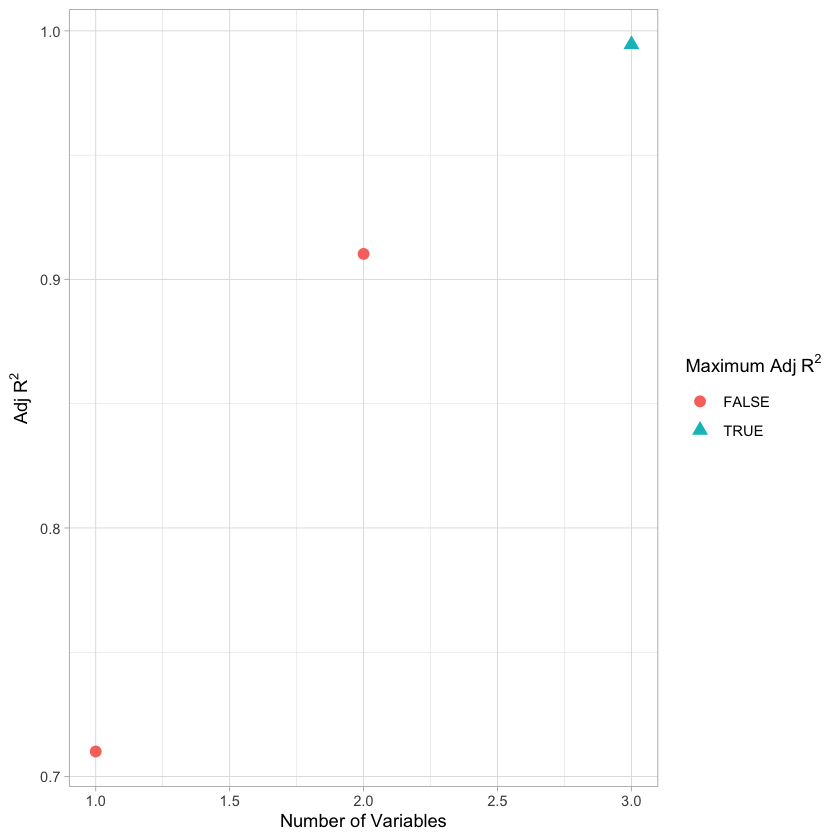

In [ ]:
adjr2_func(numvar, step_model$adjr2)

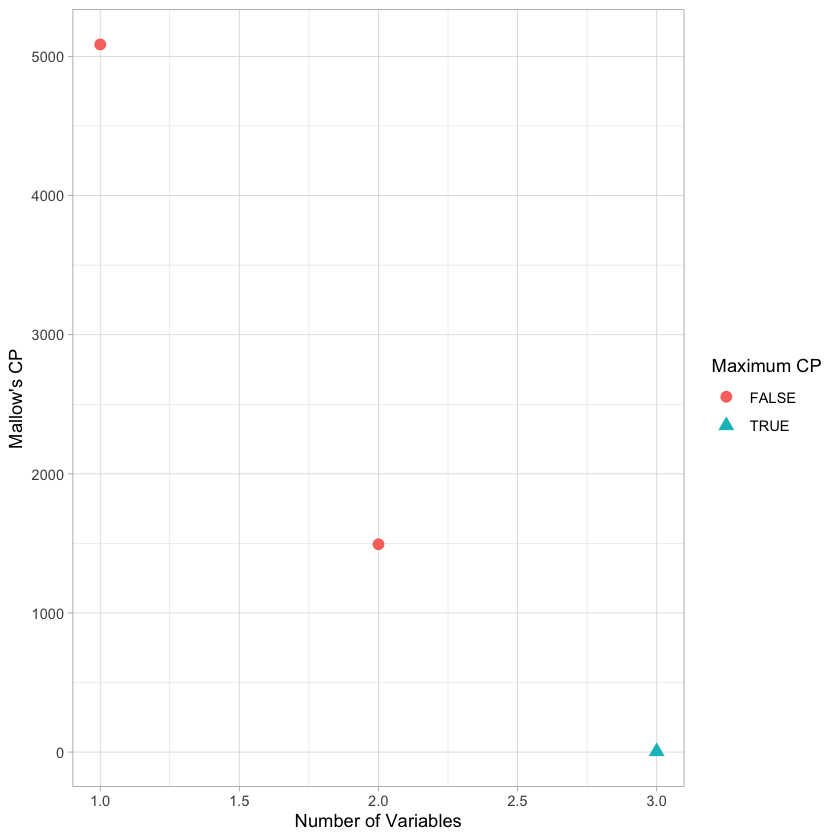

In [ ]:
cp_func(numvar, step_model$cp)

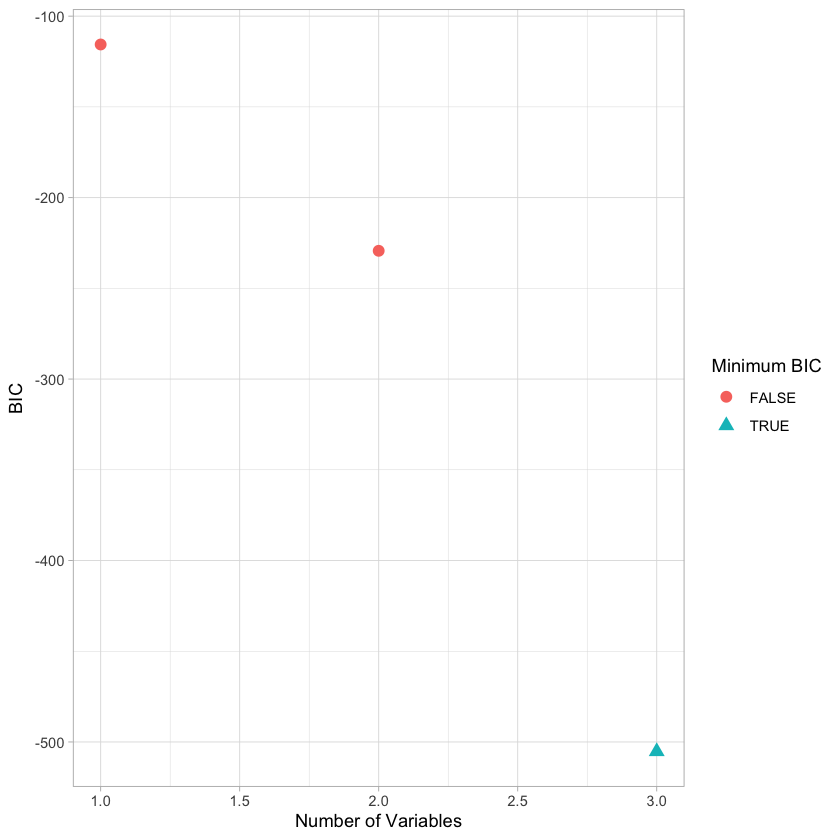

In [ ]:
bic_func(numvar, step_model$bic)

b) Backwards stepwise selection:

In [ ]:
# WRITE YOUR CODE HERE
reg <- regsubsets(y ~ poly(x, 3), data = df, method = 'backward')
step_model_back <- summary(reg)
numvar = 1:length(step_model_back$rss)# Make a vector that lists the number of variables in sequence, from 1 to 19.
allfalse = rep(FALSE,length(step_model_back$rss))
summary(reg)

Subset selection object
Call: regsubsets.formula(y ~ poly(x, 3), data = df, method = "backward")
3 Variables  (and intercept)
            Forced in Forced out
poly(x, 3)1     FALSE      FALSE
poly(x, 3)2     FALSE      FALSE
poly(x, 3)3     FALSE      FALSE
1 subsets of each size up to 3
Selection Algorithm: backward
         poly(x, 3)1 poly(x, 3)2 poly(x, 3)3
1  ( 1 ) "*"         " "         " "        
2  ( 1 ) "*"         " "         "*"        
3  ( 1 ) "*"         "*"         "*"        

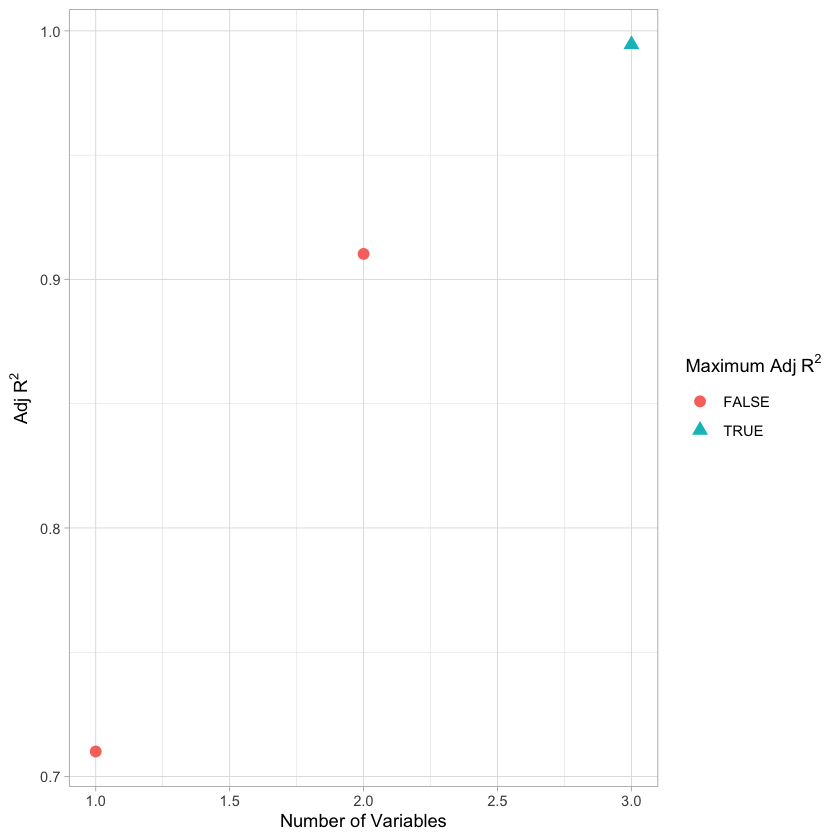

In [ ]:
adjr2_func(numvar, step_model_back$adjr2)

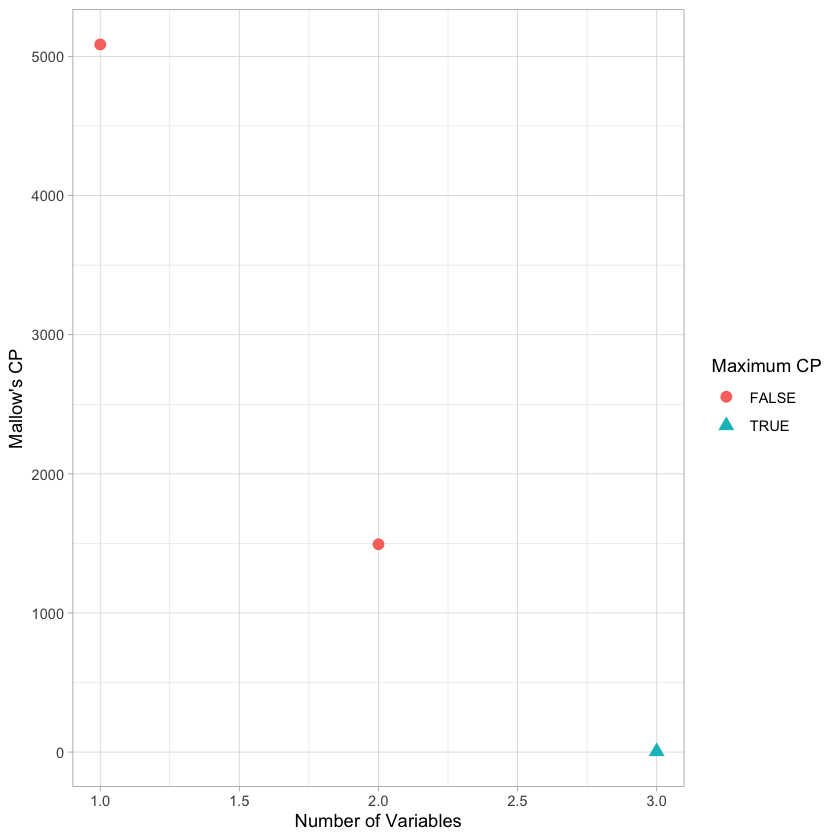

In [ ]:
cp_func(numvar, step_model_back$cp)

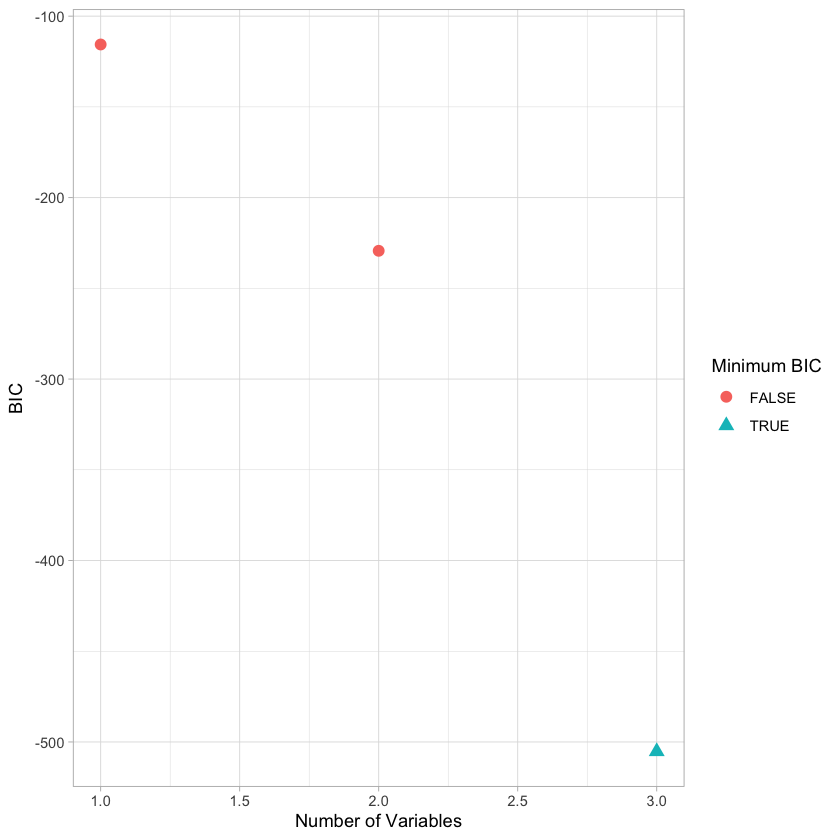

In [ ]:
bic_func(numvar, step_model_back$bic)

c) Compare your results from parts a and b with those of question 1.

> Both the forward and backward selection provide the same variables according to the corresponding model complexity.

---
## 3. Training and test error (3 points)

This question will explore the relationship between training and test error and the number of features included in a model. We will again use a simulated dataset.

a) Simulate dataset with features $p = 20$ and observations $n = 1,000$. Generate data for a response variable $Y$ according to the model

$Y = X\beta + \epsilon$

where $\beta$ is random with some elements that are exactly zero.

Split your simulated dataset into a training set containing $n=100$ observations and a test set containing $n=900$ observations.

In [ ]:
# WRITE YOUR CODE HERE

set.seed(123)
simulate_data <- function(sample_size) {
    p <- 20
    # draw observation from a normal distribution
    x <- matrix(rnorm(sample_size * p), nrow = sample_size, ncol = p)
    beta <- c(0.1, 0, 0.2, 0, 0.4, 0.3, 0, 4, 5, 6,
    2, 3, 0.7, 0.8, 0.9, 10, 12, 13, 15, 0.11)
    y <- x%*%beta + rnorm(sample_size, 0, 1)
    return(data.frame(x = x, y = y))
}

df <- simulate_data(1000)
train_100 <- sample(1:nrow(df), size = 100)

df_train <- df[train_100, ]
df_test <- df[-train_100, ]

str(df)

'data.frame':	1000 obs. of  21 variables:
 $ x.1 : num  -0.5605 -0.2302 1.5587 0.0705 0.1293 ...
 $ x.2 : num  -0.996 -1.04 -0.018 -0.132 -2.549 ...
 $ x.3 : num  -0.512 0.237 -0.542 1.219 0.174 ...
 $ x.4 : num  -0.15 -0.328 -1.448 -0.697 2.598 ...
 $ x.5 : num  0.197 0.65 0.671 -1.284 -2.026 ...
 $ x.6 : num  -0.494 1.128 -1.147 1.481 0.916 ...
 $ x.7 : num  -0.699 0.996 -0.693 -0.103 0.604 ...
 $ x.8 : num  -1.618 0.379 1.902 0.602 1.732 ...
 $ x.9 : num  0.511 1.808 -1.703 0.287 -0.269 ...
 $ x.10: num  1.932 -0.616 -0.563 -0.99 2.731 ...
 $ x.11: num  2.371 -0.167 0.927 -0.568 0.225 ...
 $ x.12: num  0.268 -0.399 0.277 -1.234 0.754 ...
 $ x.13: num  -0.151 0.801 -1.187 0.431 0.217 ...
 $ x.14: num  -1.41 -1.721 0.665 -0.431 -0.329 ...
 $ x.15: num  -0.91 0.281 -1.036 0.273 0.538 ...
 $ x.16: num  -1.354 -0.579 -0.861 0.973 0.619 ...
 $ x.17: num  -1.092 -1.338 1.109 0.811 -0.876 ...
 $ x.18: num  0.717 -0.284 -1.135 -0.633 1.351 ...
 $ x.19: num  0.278 -1.603 -0.321 -1.226 -0.777 

### Solution

In [ ]:
p = 20
n = 1000

x = matrix(rnorm(n * p), n, p)

beta = rnorm(p)
beta[3] = 0
beta[6] = 0
beta[9] = 0
beta[10] = 0
beta[18] = 0

epsilon = rnorm(p)

y = x %*% beta + epsilon

train = sample(seq(1000), 100, replace = FALSE)
y_train = y[train, ]
y_test = y[-train, ]
x_train = x[train, ]
x_test = x[-train, ]

test <- lm(y_train ~ x_train)
rownames(coef(summary(test)))

b) Perform best subset selection on the training set, and plot the associated training and test set MSE for the best model of each size.

In [ ]:
set.seed(123)

df <- simulate_data(1000)
train_indices <- sample(1:nrow(df), size = 100)

df_train <- df[train_indices, ]
df_test  <- df[-train_indices, ]

reg <- regsubsets(y ~ ., data = df_train, nvmax = 19)

coefi <- coef(reg, id = 19)

test_mat <- model.matrix(y ~ ., data = df_test)
preds <- test_mat[, names(coefi)] %*% coefi

pred_class <- ifelse(preds > 0.5, "pos", "neg")

output <- data.frame(actual = df_test$y, predicted = pred_class)

numvar = 1:length(reg.summary$rss)# Make a vector that lists the number of variables in sequence, from 1 to 19.
allfalse = rep(FALSE,length(reg.summary$rss))# Starting point for an indicator that marks the best model choice for each metric.

# #rss
rss.df <- data.frame(numvar = numvar, rss = reg.summary$rss, minrss = allfalse)
rss.df$minrss[which.min(reg.summary$rss)] <- TRUE
ggplot(rss.df,aes(x=numvar,y=rss,shape=minrss,col=minrss)) +
     geom_point(size=3) + theme_light() +
     labs(x = "Number of Variables", y = "RSS", color="Minimum RSS", shape="Minimum RSS")


### Solution

In [ ]:
models = regsubsets(y ~ ., data = data.frame(x = x_train, y = y_train), nvmax = p)
train_errors = rep(NA, p)
test_errors = rep(NA, p)
x_cols = colnames(x, do.NULL = FALSE, prefix = "x.")

for (i in 1:p) {

    coef_i = coef(models, id = i)

    pred_train = as.matrix(x_train[, x_cols %in% names(coef_i)]) %*% coef_i[names(coef_i) %in% x_cols]
    train_errors[i] = mean((y_train - pred_train)^2)

    pred_test = as.matrix(x_test[, x_cols %in% names(coef_i)]) %*% coef_i[names(coef_i) %in% x_cols]
    test_errors[i] = mean((y_test - pred_test)^2)
}

ggplot(data.frame(errors=train_errors, index = 1:20), aes(x=index, y=train_errors)) +
    geom_point() +
    geom_line() +
    xlab("Subset size") +
    ylab("Training MSE")

ggplot(data.frame(errors=test_errors, index = 1:20), aes(x=index, y=test_errors)) +
    geom_point() +
    geom_line() +
    xlab("Subset size") +
    ylab("Test MSE")

c) Identify the best model according the test MSE. How does this model compare to the actual model used to simulate the dataset?

*Note: If the model identified contains only an intercept or all of the features, then generate a new dataset (i.e. repeat part a with a different random seed) until the test set MSE is minimized for an intermediate model size.*

In [ ]:
# WRITE YOUR CODE HERE



### Solution

In [ ]:
best_model <- which.min(test_errors)
best_model

best_model_coefs <- coef(models, id=best_model)
best_model_coefs

beta

> *Write your response here*
> * The 17 parameter model has the smallest test MSE.
> * Some estimated coefficients are quite similar to the actual beta values, however the selected predictor variables are not identical.

**DUE:** 5pm EST, April 8, 2024

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*